In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_ta as ta # Professional Technical Analysis library
from sklearn.preprocessing import MinMaxScaler

In [2]:
from datetime import date

In [3]:
from datetime import date
today = date.today().strftime('%Y-%m-%d')

df = yf.download("NVDA", start="2020-01-01", end=today)

# 👇 ADD THIS LINE RIGHT HERE
df.columns = df.columns.droplevel(1)


C:\Users\mayank goyal\AppData\Local\Temp\ipykernel_26440\1212261097.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("NVDA", start="2020-01-01", end=today)
c:\Users\mayank goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\scrapers\history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed


In [4]:
df.shape

(1552, 5)

In [5]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [6]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1552 entries, 2020-01-02 to 2026-03-06
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1552 non-null   float64
 1   High    1552 non-null   float64
 2   Low     1552 non-null   float64
 3   Open    1552 non-null   float64
 4   Volume  1552 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 72.8 KB


In [7]:
df.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [8]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,5.971078,5.971078,5.891683,5.942207,237536000
2020-01-03,5.875505,5.919309,5.826474,5.851363,205384000
2020-01-06,5.900144,5.905370,5.756038,5.782171,262636000
2020-01-07,5.971574,6.017370,5.883468,5.928517,314856000
2020-01-08,5.982775,6.024091,5.927273,5.967344,277108000


In [9]:
df['Open_Gap'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)

In [10]:
df['Vol_Range'] = (df['High'] - df['Low']) / df['Close']

In [11]:
df['RSI'] = ta.rsi(df['Close'], length=14)

In [12]:
df['ATR'] = ta.atr(df['High'], df['Low'], df['Close'], length=14)

In [14]:
bbands = ta.bbands(df['Close'], length=20, std=2)
print(bbands.columns.tolist())   # 👈 Add this line to see the real names


['BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'BBU_20_2.0_2.0', 'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0']


In [15]:
bbands = ta.bbands(df['Close'], length=20, std=2)

if bbands is not None:
    # Dynamically find the lower and upper band columns
    bbl_col = [c for c in bbands.columns if 'BBL' in c][0]
    bbu_col = [c for c in bbands.columns if 'BBU' in c][0]
    df['BBP'] = (df['Close'] - bbands[bbl_col]) / (bbands[bbu_col] - bbands[bbl_col])
    print(f"✅ BBP calculated using columns: {bbl_col}, {bbu_col}")
else:
    df['BBP'] = np.nan
    print("❌ Bollinger Bands failed!")


✅ BBP calculated using columns: BBL_20_2.0_2.0, BBU_20_2.0_2.0


In [16]:
len(df)
print("Missing close prices:", df['Close'].isna().sum())


Missing close prices: 0


In [17]:
df.dropna(inplace=True)

### DATA SCALING

In [ ]:
print("Rows in dataset before scaling:", len(df))


Rows in dataset before scaling: 0


In [ ]:
print(df.isna().sum())
print("Total rows before dropna:", len(df))


Price      Ticker
Close      NVDA      0
High       NVDA      0
Low        NVDA      0
Open       NVDA      0
Volume     NVDA      0
Open_Gap             0
Vol_Range            0
RSI                  0
ATR                  0
BBP                  0
dtype: int64
Total rows before dropna: 0


In [18]:
features = ['Open_Gap', 'RSI', 'ATR', 'BBP', 'Vol_Range']
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[features])

In [19]:
# --- STEP 3: CREATING SEQUENCES (The 30-Day 'Memory') ---
def create_sequences(data, window_size=30):
    X, y = [], []
    for i in range(window_size, len(data)):
        # Inputs: All 5 features for the last 30 days
        X.append(data[i-window_size:i])
        # Target: Today's Volatility Range (the last column in our feature list)
        y.append(data[i, -1]) 
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

# --- STEP 4: TRAIN/TEST SPLIT ---
# We keep the most recent 20% of days for testing our 'Daily Trading' accuracy
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"✅ Data Pipeline Built!")
print(f"Training Samples: {len(X_train)} | Testing Samples: {len(X_test)}")

✅ Data Pipeline Built!
Training Samples: 1202 | Testing Samples: 301


In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [21]:
model = Sequential()

# Layer 1: Deep Memory
# We use return_sequences=True because we are stacking another LSTM on top
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2)) # Randomly shuts off 20% of neurons to stop overfitting

# Layer 2: Pattern Recognition
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Layer 3: The Output
# 1 unit because we are predicting ONE number (Tomorrow's Volatility)
model.add(Dense(units=1))

# 2. Compile
# 'adam' is the smart optimizer; 'mse' (Mean Squared Error) is the standard for price/vol projects
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

c:\Users\mayank goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,451 (122.86 KB)

 Trainable params: 31,451 (122.86 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    X_train, y_train, 
    epochs=25, 
    batch_size=32, 
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0158 - val_loss: 0.0163
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0139 - val_loss: 0.0158
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0136 - val_loss: 0.0151
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0131 - val_loss: 0.0152
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0143 - val_loss: 0.0178
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0131 - val_loss: 0.0146
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0128 - val_loss: 0.0156
Epoch 8/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0123 - val_loss: 0.0141
Epoch 9/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0128 - val_loss: 0.0150
Epoch 10/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0125 - val_loss: 0.0135
Epoch 11/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0123 - val_loss: 0.0137
Epoch 12/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0

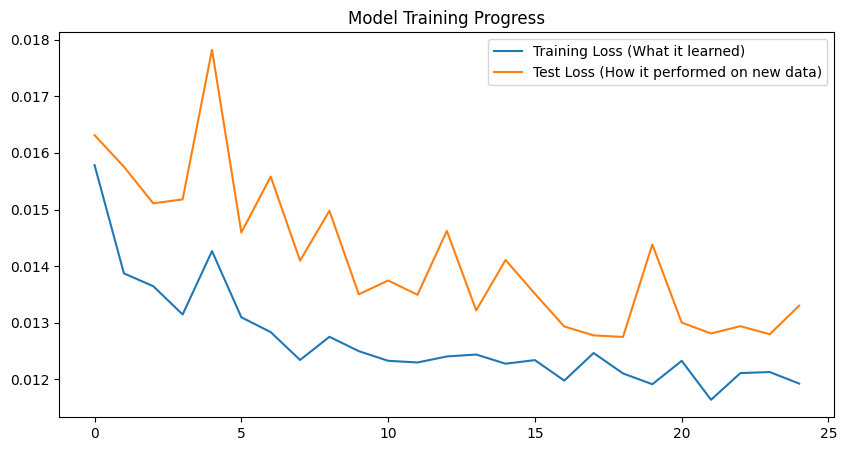

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss (What it learned)')
plt.plot(history.history['val_loss'], label='Test Loss (How it performed on new data)')
plt.title('Model Training Progress')
plt.legend()
plt.show()

In [25]:
# 1. Re-defining the missing variable
ticker = "NVDA" 

# 2. Grab the last 30 days of scaled data (The 'Input Window')
# We reshape it to (1, 30, 5) because the LSTM expects: [Batch, TimeSteps, Features]
last_30_days = scaled_data[-30:].reshape(1, 30, X.shape[2])

# 3. Get the prediction from our trained 'Brain'
predicted_vol_scaled = model.predict(last_30_days)

# 4. 'De-Scaling' the result
# We create a dummy row to match the scaler's 5-column shape requirement
# We put our prediction in the last column (where Vol_Range lived)
dummy = np.zeros((1, len(features)))
dummy[0, -1] = predicted_vol_scaled[0, 0] 
predicted_vol = scaler.inverse_transform(dummy)[0, -1]

# 5. --- 🔮 THE REVEAL ---
print(f"--- 🔮 MORNING FORECAST FOR {ticker} ---")
print(f"Predicted Daily Price Swing: {predicted_vol * 100:.2f}%")

# 🚦 THE TRAFFIC LIGHT LOGIC
avg_vol = df['Vol_Range'].mean()
if predicted_vol > avg_vol * 1.5:
    print("🚦 STATUS: RED - Extreme Volatility! Market is shaking. 🚩")
elif predicted_vol > avg_vol:
    print("🚦 STATUS: YELLOW - Elevated Risk. Proceed with caution. ⚠️")
else:
    print("🚦 STATUS: GREEN - Low Volatility. Smooth sailing. ✅")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
--- 🔮 MORNING FORECAST FOR NVDA ---
Predicted Daily Price Swing: 4.00%
🚦 STATUS: YELLOW - Elevated Risk. Proceed with caution. ⚠️


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  


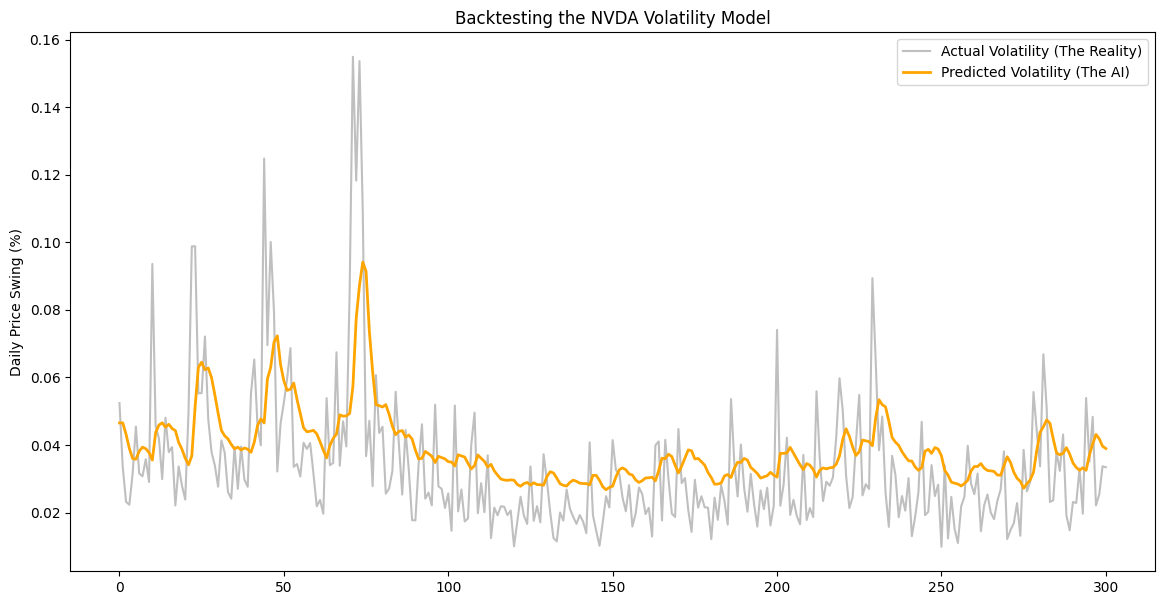

In [26]:
# 1. Get all predictions for our Test Set
test_predictions_scaled = model.predict(X_test)

# 2. De-scale the predictions to get real percentages
# We create a dummy matrix to match the 5-column shape the scaler expects
dummy_test = np.zeros((len(test_predictions_scaled), len(features)))
dummy_test[:, -1] = test_predictions_scaled.flatten()
test_predictions = scaler.inverse_transform(dummy_test)[:, -1]

# 3. De-scale the actual 'y_test' values for comparison
dummy_actual = np.zeros((len(y_test), len(features)))
dummy_actual[:, -1] = y_test.flatten()
actual_vol = scaler.inverse_transform(dummy_actual)[:, -1]

# 4. 📈 VISUALIZE: The Reality Check
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(actual_vol, label='Actual Volatility (The Reality)', color='gray', alpha=0.5)
plt.plot(test_predictions, label='Predicted Volatility (The AI)', color='orange', linewidth=2)
plt.title(f'Backtesting the {ticker} Volatility Model')
plt.ylabel('Daily Price Swing (%)')
plt.legend()
plt.show()

In [27]:
# 1. Define a 'Danger Zone' threshold (e.g., predicted swing > 6%)
danger_threshold = 0.06 

# 2. Compare 'Always Trading' vs 'Smart Trading' (Sitting out on Red Days)
# This is where you prove the model's value to a boss! 💼
print(f"--- 🛡️ RISK MANAGEMENT REPORT: {ticker} ---")
total_days = len(test_predictions)
danger_days = np.sum(test_predictions > danger_threshold)

print(f"Total Trading Days: {total_days}")
print(f"Danger Days Detected: {danger_days}")
print(f"Safety Accuracy: The model flagged {((danger_days/total_days)*100):.1f}% of days as high-risk.")

--- 🛡️ RISK MANAGEMENT REPORT: NVDA ---
Total Trading Days: 301
Danger Days Detected: 14
Safety Accuracy: The model flagged 4.7% of days as high-risk.
